In [23]:
import numpy as np
import matplotlib.pyplot as plt

In [24]:
# fungsi asli tanpa noise 
def f(x):
    return 2 * np.sin(x) + 0.5 * x

# generate 80 data x acak dari 0 sampai 30
x = np.random.uniform(0.0, 30.0, 80)

# generate nilai noise
noise = np.random.uniform(-0.5, 0.5, 80)

# hitung y dari fungsi + noise
y = f(x) + noise

# print data hasil generate
for i in range(len(x)):
    print("x =", round(x[i],2), " y =", round(y[i],2))

# urutkan data 
idx = np.argsort(x)
x = x[idx]
y = y[idx]

# nilai minimum dan maksimum x
xmin = np.min(x)
xmax = np.max(x)

# generate xp (tidak dipakai semua)
xp = np.random.uniform(xmin, xmax, 8)

# print xp
for i in range(len(xp)):
    print("xp"+str(i+1), "=", round(xp[i],2))


x = 2.89  y = 1.56
x = 24.41  y = 11.01
x = 2.05  y = 2.85
x = 11.25  y = 3.2
x = 15.64  y = 8.35
x = 15.02  y = 9.28
x = 3.83  y = 0.82
x = 29.9  y = 13.03
x = 12.44  y = 5.85
x = 12.6  y = 5.92
x = 8.57  y = 5.54
x = 9.75  y = 4.7
x = 4.66  y = -0.14
x = 26.71  y = 15.83
x = 10.03  y = 3.72
x = 17.89  y = 7.75
x = 21.6  y = 11.43
x = 0.31  y = 0.62
x = 23.99  y = 9.91
x = 19.67  y = 11.43
x = 4.56  y = 0.76
x = 12.08  y = 5.08
x = 27.38  y = 15.41
x = 13.23  y = 7.86
x = 2.69  y = 2.3
x = 18.65  y = 8.83
x = 19.48  y = 10.6
x = 7.93  y = 5.66
x = 13.7  y = 9.12
x = 10.92  y = 3.29
x = 19.16  y = 10.26
x = 7.63  y = 5.44
x = 6.53  y = 3.58
x = 15.32  y = 8.79
x = 11.02  y = 3.58
x = 25.12  y = 12.88
x = 20.59  y = 12.09
x = 21.9  y = 11.22
x = 4.99  y = 0.72
x = 15.22  y = 8.05
x = 14.93  y = 8.8
x = 15.14  y = 8.66
x = 3.04  y = 1.9
x = 2.28  y = 2.88
x = 6.73  y = 4.59
x = 13.96  y = 8.62
x = 4.73  y = -0.09
x = 28.11  y = 14.7
x = 29.94  y = 13.46
x = 25.4  y = 13.01
x = 6.28  y = 

In [25]:
# fungsi interpolasi newton
def newton(x, fx, orde, x_baru):

    # code interpolasi newron di praktikum pakai data dictionary dan sort berdasarkan jarak
    # kalau di sini pakai array langsung dan tetap ambil titik terdekat

    # bagian yang ditambahkan:
    # ambil titik terdekat berdasarkan jarak ke x_baru
    dist = np.abs(x - x_baru)

    # ambil indeks titik terdekat sebanyak orde+1
    idx = np.argsort(dist)[:orde+1]

    # ambil nilai x dan fx dari titik tersebut
    x_temp = x[idx]
    fx_temp = fx[idx]

    # bagian ini sama konsep dengan kode dosen:
    # membuat tabel divided difference
    n = orde + 1
    b = np.zeros((n, n))

    # kolom pertama diisi dengan nilai fx
    b[:,0] = fx_temp

    # menghitung divided difference
    # ini sama seperti kode dosen, hanya tanpa print
    for j in range(1, n):
        for i in range(n - j):
            b[i,j] = (b[i+1,j-1] - b[i,j-1]) / (x_temp[i+j] - x_temp[i])

    # hitung nilai interpolasi
    yp = b[0,0]
    xt = 1

    for j in range(1, n):
        xt = xt * (x_baru - x_temp[j-1])
        yp = yp + b[0,j] * xt

    return yp, b

In [26]:
# xp konstan (dipilih di tengah domain)
p = (xmin + xmax) / 2

# nilai asli tanpa noise
y_true = f(p)

print("\nhasil interpolasi newton\n")
print("xp =", round(p,2))

# list untuk grafik
orde = []
errors = []

# loop semua orde
for n in range(1, 11):

    yp, b = newton(x, y, n, p)
    error = abs(yp - y_true)

    # simpan untuk grafik
    orde.append(n)
    errors.append(error)

    # simpan yp untuk orde tertentu
    if n == 1:
        yp1 = yp
    elif n == 5:
        yp5 = yp
    elif n == 10:
        yp10 = yp

    print("orde =", n)

    # print b0, b1, dst
    for j in range(n+1):
        print(f"b{j} =", round(b[0,j], 4))

    print("yp =", round(yp, 4))
    print("error =", round(error, 4))
    print()

# yg dipakai buat grafik
print("yp orde 1 =", yp1)
print("yp orde 5 =", yp5)
print("yp orde 10 =", yp10)


hasil interpolasi newton

xp = 15.03
orde = 1
b0 = 9.2773
b1 = 5.9655
yp = 9.3866
error = 0.6212

orde = 2
b0 = 9.2773
b1 = 5.9655
b2 = -53.1077
yp = 9.2904
error = 0.525

orde = 3
b0 = 9.2773
b1 = 5.9655
b2 = -53.1077
b3 = 141.4072
yp = 9.2632
error = 0.4978

orde = 4
b0 = 9.2773
b1 = 5.9655
b2 = -53.1077
b3 = 141.4072
b4 = 444.4264
yp = 9.2792
error = 0.5138

orde = 5
b0 = 9.2773
b1 = 5.9655
b2 = -53.1077
b3 = 141.4072
b4 = 444.4264
b5 = -1797.7367
yp = 9.2978
error = 0.5324

orde = 6
b0 = 9.2773
b1 = 5.9655
b2 = -53.1077
b3 = 141.4072
b4 = 444.4264
b5 = -1797.7367
b6 = -1474.9724
yp = 9.2885
error = 0.5231

orde = 7
b0 = 9.2773
b1 = 5.9655
b2 = -53.1077
b3 = 141.4072
b4 = 444.4264
b5 = -1797.7367
b6 = -1474.9724
b7 = -853.3491
yp = 9.2845
error = 0.5191

orde = 8
b0 = 9.2773
b1 = 5.9655
b2 = -53.1077
b3 = 141.4072
b4 = 444.4264
b5 = -1797.7367
b6 = -1474.9724
b7 = -853.3491
b8 = 29.078
yp = 9.2846
error = 0.5192

orde = 9
b0 = 9.2773
b1 = 5.9655
b2 = -53.1077
b3 = 141.4072
b4 = 444

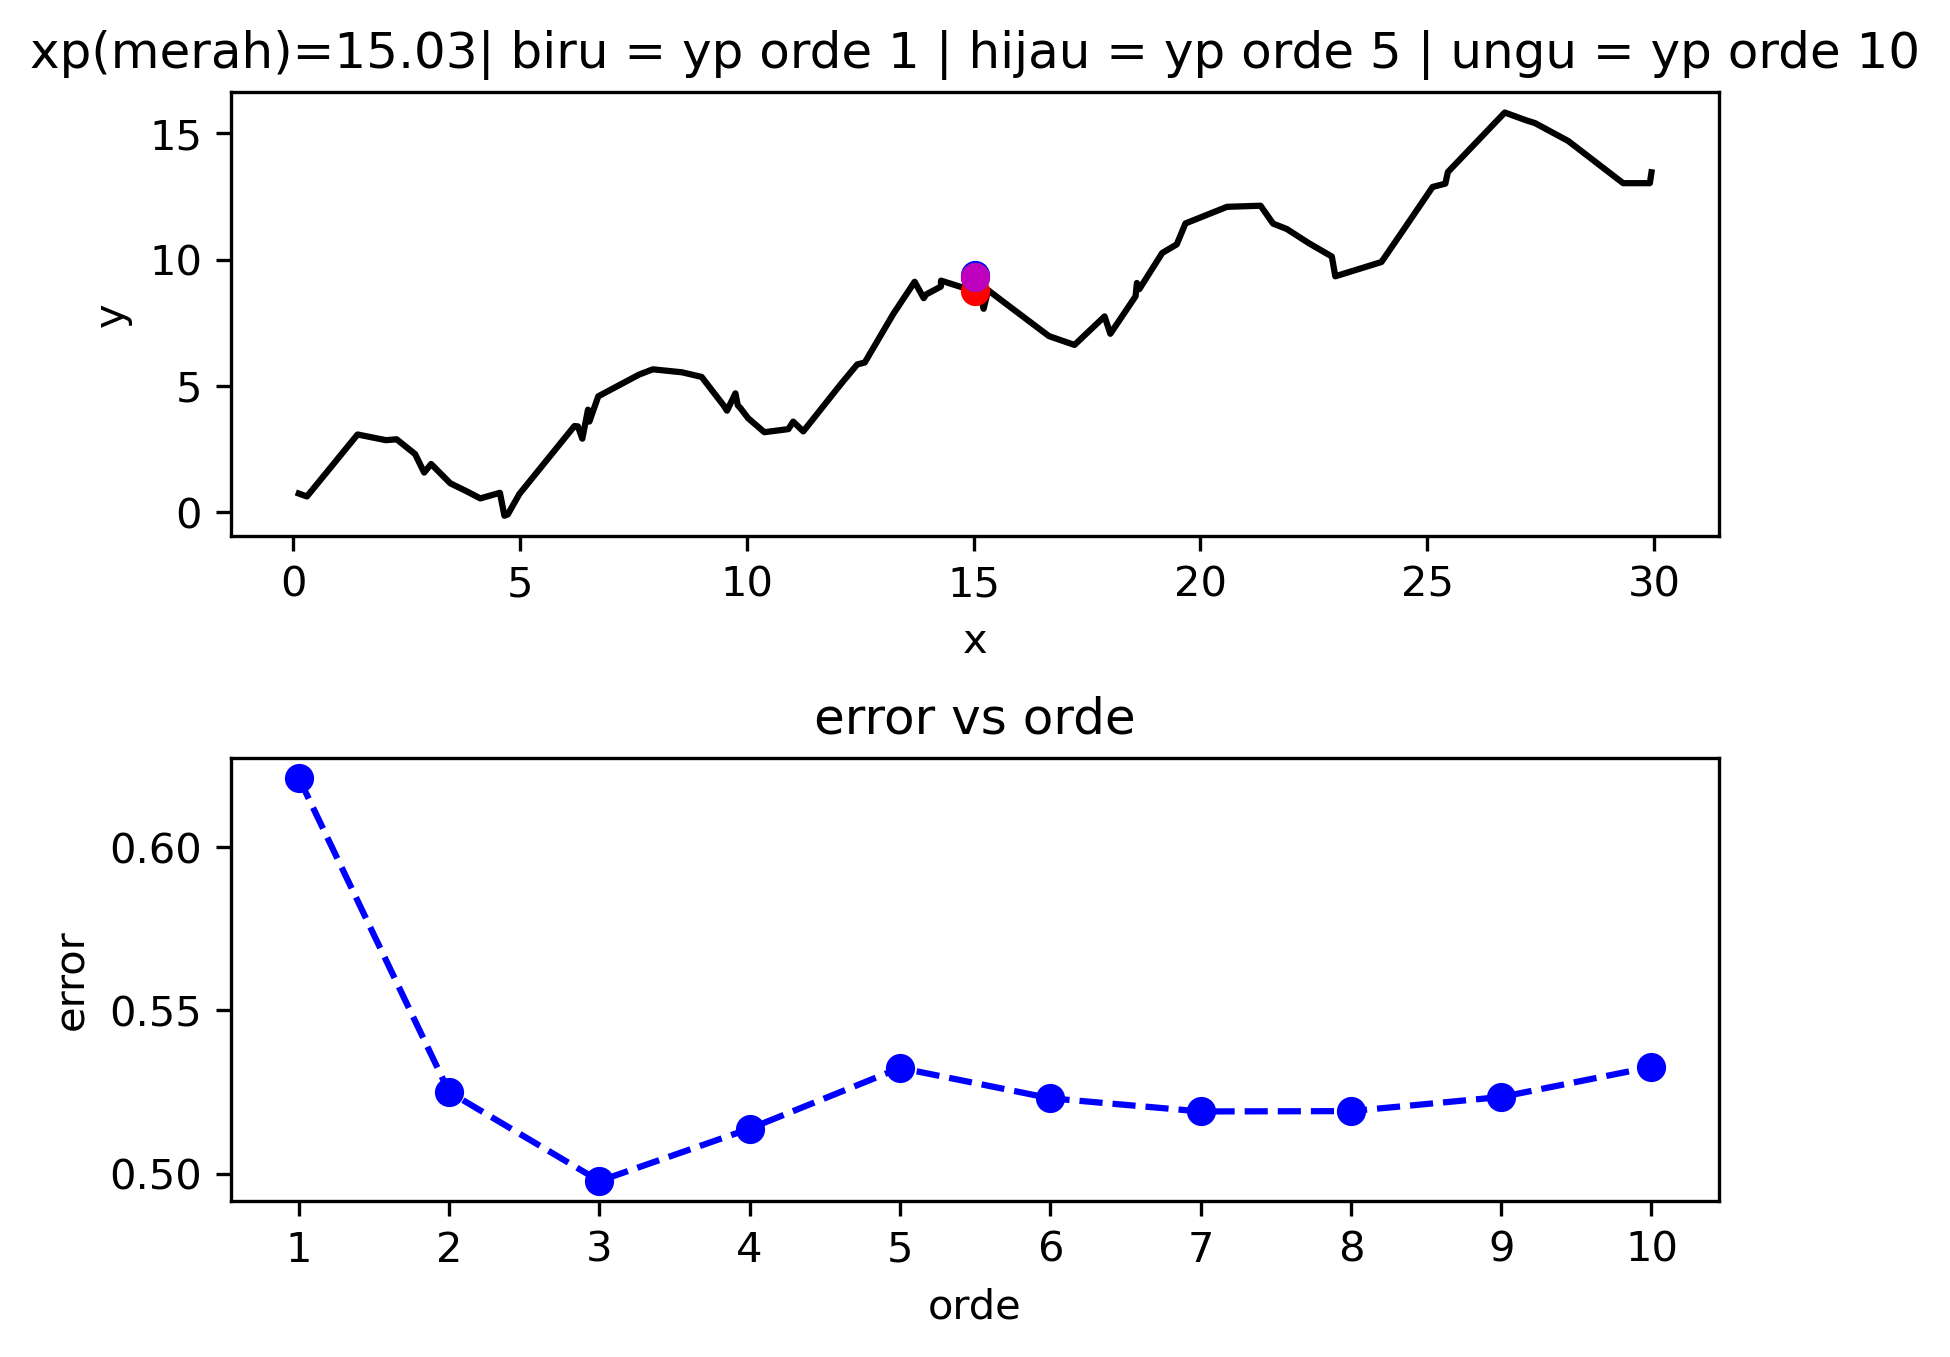

In [27]:
# visualisasi
plt.figure(dpi=300)
# grafik pertama
plt.subplot(211)
# garis hitam menunjukkan data (x, y) hasil generate
plt.plot(x, y, 'k-')
# titik merah menunjukkan posisi xp yang akan diinterpolasi
plt.plot(p, f(p), 'ro')
# titik biru, hijau, dan ungu menunjukkan hasil interpolasi (yp) untuk orde berbeda
plt.plot(p, yp1, 'bo')
plt.plot(p, yp5, 'go')
plt.plot(p, yp10, 'mo')
plt.xlabel("x")
plt.ylabel("y")
plt.title("xp(merah)=" + str(round(p,2)) + "| biru = yp orde 1 | hijau = yp orde 5 | ungu = yp orde 10")

# grafik kedua
plt.subplot(212)
plt.plot(orde, errors, 'bo--')
plt.xticks(range(1,11))
plt.xlabel("orde")
plt.ylabel("error")
plt.title("error vs orde")
plt.subplots_adjust(hspace=0.5)
plt.savefig("Interpolasi Newton.png")
plt.show()